In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
# 读取CSV文件
df = pd.read_csv('robot_data.csv')

# 获取并输出列标题
column_titles = df.columns.tolist()
print('Column titles:')
print(column_titles)

Column titles:
['timestamp', 'target_qd_0', 'target_qd_1', 'target_qd_2', 'target_qd_3', 'target_qd_4', 'target_qd_5', 'actual_q_0', 'actual_q_1', 'actual_q_2', 'actual_q_3', 'actual_q_4', 'actual_q_5', 'actual_qd_0', 'actual_qd_1', 'actual_qd_2', 'actual_qd_3', 'actual_qd_4', 'actual_qd_5']


In [22]:
time = df['timestamp'].to_numpy()
# z = df['actual_TCP_pose_2'].to_numpy()
# vz = df['actual_TCP_speed_2'].to_numpy()
q6 = df['actual_q_5'].to_numpy()
t_qd6 = df['target_qd_5'].to_numpy()
qd6 = df['actual_qd_5'].to_numpy()

# 计算指数移动加权平均
def exponential_moving_average(data, alpha):
    ema = np.zeros_like(data)
    ema[0] = data[0]
    for i in range(1, len(data)):
        ema[i] = alpha * data[i] + (1 - alpha) * ema[i - 1]
    return ema

# 设置平滑系数
alpha = 0.1
filtered_q6 = exponential_moving_average(q6, alpha)

def compute_derivative(data, time):
    n = len(data)
    derivative = np.zeros(n)
    
    # 使用五点差分公式计算导数
    for i in range(2, n - 2):
        dt1 = time[i+1] - time[i]
        dt2 = time[i] - time[i-1]
        h = (dt1 + dt2) / 2
        derivative[i] = (-data[i + 2] + 8 * data[i + 1] - 8 * data[i - 1] + data[i - 2]) / (12 * h)
    
    # 使用较低阶公式计算边界点的导数
    derivative[0] = (data[1] - data[0]) / (time[1] - time[0])  # 前向差分
    derivative[1] = (data[2] - data[1]) / (time[2] - time[1])  # 前向差分
    derivative[-2] = (data[-2] - data[-3]) / (time[-2] - time[-3])  # 后向差分
    derivative[-1] = (data[-1] - data[-2]) / (time[-1] - time[-2])  # 后向差分
    
    return derivative

derivative = compute_derivative(filtered_q6, time)

<function matplotlib.pyplot.show(close=None, block=None)>

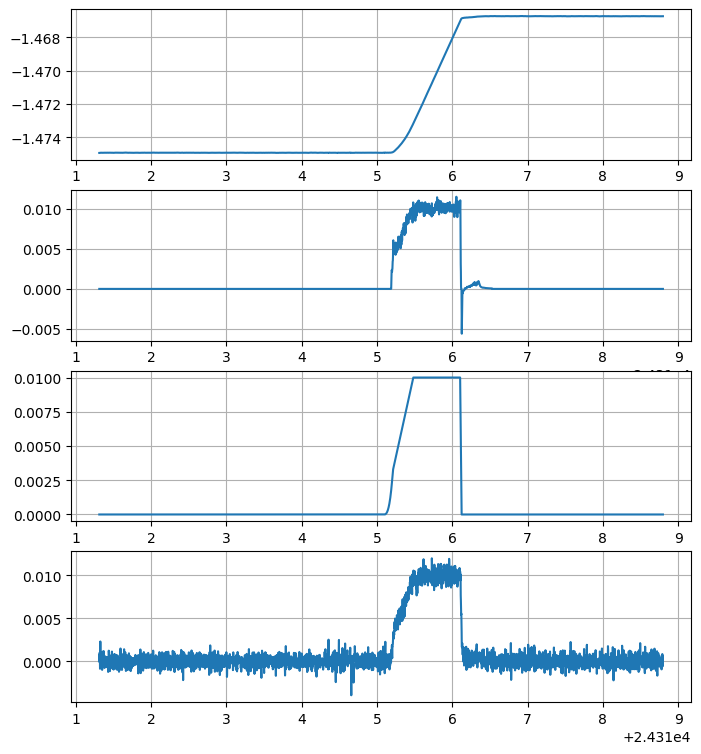

In [23]:
fig, axs = plt.subplots(4, 1, figsize=(8, 9))
axs[0].plot(time, filtered_q6)
axs[0].grid('True')

axs[1].plot(time, qd6)
axs[1].grid('True')

axs[2].plot(time, t_qd6)
axs[2].grid('True')

axs[3].plot(time, derivative)
axs[3].grid('True')

plt.show

In [ ]:
"""
期望速度不是方形，导致移动的距离不等于速度*时间
"""